# Station-MAE — Test-Results Exploration

Loads the raw `predictions.pt` files saved by `test.py` at two encoder mask
ratios and computes **real error metrics in physical units**.

- **mr0.00** — all stations visible to the encoder (pure temporal forecast)
- **mr0.50** — 50 % of stations masked (trained gap-fill + forecast)

**Focus:** MAE and MSE, plus a few metrics that expose *error variability*
(RMSE, bias, error std, RMSE/MAE ratio, |error| percentiles, growth with lead-time)
— these are not captured by MAE/MSE alone.

**Un-normalisation.** The run uses **per-station** normalisation (train stats reused
at test — the `test.py` default). So the *correct* physical error at station *s* is
`err_phys = err_norm × std_train[s, v]`. We also report a **global-std reference
scale** (`err_norm × global_std[v]`) for cross-station-comparable magnitudes, exactly
as requested. A self-check confirms the per-station stats reproduce the stored targets.

In [11]:
# ── Config & imports ─────────────────────────────────────────────────────────
import os, sys, csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.dirname(os.path.abspath(".")))

RESULTS_DIR = "test_results/v11"                     # holds best_mr0.00/ and best_mr0.50/
PRED_FILES  = {"mr0.00": os.path.join(RESULTS_DIR, "best_mr0.00", "predictions.pt"),
               "mr0.50": os.path.join(RESULTS_DIR, "best_mr0.50", "predictions.pt")}
EXCLUDE     = ["PFA"]        # same station excluded at train/eval time
GLOBAL_NORM = False          # False = per-station (matches run_test_cloud.sh default)

_CANDIDATES = [
    "/home/renku/work/PeakWeatherDataset",
    os.path.expanduser("~/Documents/ETH/_DAS Project/PeakWeatherDataset"),
    os.path.expanduser("~/PeakWeatherDataset"),
    "PeakWeatherDataset",
]
DATA_ROOT = next((p for p in _CANDIDATES if os.path.isdir(p)), _CANDIDATES[-1])

VARS  = ["temperature", "pressure", "humidity", "wind_u", "wind_v"]   # 5 target vars
UNITS = {"temperature":"°C","pressure":"hPa","humidity":"%","wind_u":"m/s","wind_v":"m/s"}
plt.rcParams.update({"figure.dpi":110, "font.size":10})
print("Results dir:", RESULTS_DIR, "| Data root:", DATA_ROOT,
      "(found)" if os.path.isdir(DATA_ROOT) else "(missing)")

Results dir: test_results/v11 | Data root: /Users/aureliedejong/Documents/ETH/_DAS Project/PeakWeatherDataset (found)


In [12]:
# ── Load the two prediction files ────────────────────────────────────────────
import torch

def load_pred(path):
    d = torch.load(path, map_location="cpu", weights_only=False)
    return {k: (v.numpy() if torch.is_tensor(v) else v) for k, v in d.items()}

PRED = {mr: load_pred(p) for mr, p in PRED_FILES.items()}

for mr, d in PRED.items():
    print(f"{mr}: preds {d['preds'].shape}  targets {d['targets'].shape}  "
          f"masks {d['masks'].shape}  vars={d['var_names']}")
# preds: (M, K, N, 5) | targets/masks: (M, K, N, 6) | delta_steps: (M, K)
N_STATIONS = PRED["mr0.00"]["preds"].shape[2]
DELTA_GRID = PRED["mr0.00"]["delta_steps"][0].astype(int)          # e.g. [0,3,...,36]
print("Stations:", N_STATIONS, "| lead-times (steps):", DELTA_GRID,
      "→ minutes:", (DELTA_GRID*10).tolist())

mr0.00: preds (200, 13, 155, 5)  targets (200, 13, 155, 6)  masks (200, 13, 155, 6)  vars=['temperature', 'pressure', 'humidity', 'wind_u', 'wind_v']
mr0.50: preds (200, 13, 155, 5)  targets (200, 13, 155, 6)  masks (200, 13, 155, 6)  vars=['temperature', 'pressure', 'humidity', 'wind_u', 'wind_v']
Stations: 155 | lead-times (steps): [ 0  3  6  9 12 15 18 21 24 27 30 33 36] → minutes: [0, 30, 60, 90, 120, 150, 180, 210, 240, 270, 300, 330, 360]


## 1. Normalisation statistics (train split, reused at test)

We recompute the exact statistics `test.py` used: **per-station** train stats for the
correct physical scale, and **global** per-variable stats for the common reference
scale. Stats are computed on all training stations then sliced to the kept stations
(same `_keep_indices` as the dataset), so they align with the prediction station axis.

In [13]:
# ── Recompute train-split stats exactly as the eval pipeline does ────────────
std_ps = mean_ps = None        # per-station (N, 5)
g_std  = g_mean  = None        # global (5,)
try:
    from data.dataset import load_peakweather, compute_obs_stats, StationMAEDataset
    ds = load_peakweather(root=DATA_ROOT)

    keep = StationMAEDataset._resolve_keep_indices(ds, EXCLUDE)   # kept station positions
    assert len(keep) == N_STATIONS, (
        f"kept stations ({len(keep)}) != predictions N ({N_STATIONS}); "
        f"check EXCLUDE={EXCLUDE}")

    # Per-station (correct physical scale)
    st_ps  = compute_obs_stats(ds, train_years=None, per_station=True)   # (N_full, 6)
    std_ps  = st_ps["std"].numpy()[keep][:, :5]     # (N, 5) target vars
    mean_ps = st_ps["mean"].numpy()[keep][:, :5]

    # Global (common reference scale)
    st_g  = compute_obs_stats(ds, train_years=None, per_station=False)   # (6,)
    g_std  = st_g["std"].numpy()[:5]
    g_mean = st_g["mean"].numpy()[:5]
    print("Per-station std shape:", std_ps.shape)
    print("Global std per variable:", {v: round(float(g_std[i]),2) for i,v in enumerate(VARS)})
except Exception as e:
    print("Could not load PeakWeather for stats:", repr(e))
    print("Falling back to GLOBAL std from test_metrics.csv (phys/norm ratio).")
    r = list(csv.DictReader(open(os.path.join(RESULTS_DIR, VERSION, "test_metrics.csv"))))[0]
    g_std  = np.array([float(r[f"{v}_rmse"]) / float(r[f"{v}_norm_rmse"]) for v in VARS])
    g_mean = np.zeros(5)
    print("Global std (from csv):", {v: round(float(g_std[i]),2) for i,v in enumerate(VARS)})
    print("⚠️  Per-station denorm unavailable without the dataset — physical metrics "
          "below will use the global scale only.")

Per-station std shape: (155, 5)
Global std per variable: {'temperature': 8.79, 'pressure': 82.12, 'humidity': 20.33, 'wind_u': 2.63, 'wind_v': 2.51}


In [4]:
# ── Self-check: do the per-station stats reproduce the stored targets? ───────
# Un-normalise the stored (normalised) targets and verify the values are physical.
if std_ps is not None:
    d = PRED["mr0.00"]
    t_norm = d["targets"][..., :5]
    m      = d["masks"][..., :5] > 0.5
    t_phys = t_norm * std_ps[None, None, :, :] + mean_ps[None, None, :, :]
    print("Un-normalised TARGET ranges (per-station denorm) — should be physical:")
    for vi, v in enumerate(VARS):
        vals = t_phys[..., vi][m[..., vi]]
        print(f"  {v:12s} min={vals.min():8.2f}  mean={vals.mean():8.2f}  "
              f"max={vals.max():8.2f}  {UNITS[v]}")
    print("\nIf any range is implausible (e.g. temperature in the hundreds), the run "
          "likely used the OTHER normalisation → set GLOBAL_NORM accordingly.")
else:
    print("Per-station stats unavailable — skipping self-check.")

Un-normalised TARGET ranges (per-station denorm) — should be physical:
  temperature  min=  -25.50  mean=    1.31  max=   22.80  °C
  pressure     min=  625.30  mean=  898.62  max= 1015.00  hPa
  humidity     min=    0.80  mean=   74.14  max=  100.00  %
  wind_u       min=  -30.13  mean=    0.47  max=   25.41  m/s
  wind_v       min=  -21.49  mean=   -0.03  max=   25.14  m/s

If any range is implausible (e.g. temperature in the hundreds), the run likely used the OTHER normalisation → set GLOBAL_NORM accordingly.


## 2. Error metrics (physical units)

Primary: **MAE** and **MSE**. Added variability indicators: **RMSE** (large-error
sensitivity), **bias** (systematic offset), **error std**, **RMSE/MAE** (≈1.25 for a
normal error law; higher ⇒ heavier tails), and **|error| percentiles**.

In [14]:
# ── Metric engine ────────────────────────────────────────────────────────────
def phys_errors(d, scale="per_station"):
    """Return dict var -> physical error array (M,K,N) and mask (M,K,N)."""
    err_norm = d["preds"] - d["targets"][..., :5]        # (M,K,N,5) normalised error
    mask     = d["masks"][..., :5] > 0.5
    if scale == "per_station" and std_ps is not None:
        err = err_norm * std_ps[None, None, :, :]
    else:                                                 # global reference scale
        err = err_norm * g_std[None, None, None, :]
    return err, mask

def variable_metrics(err, mask):
    rows = {}
    for vi, v in enumerate(VARS):
        e = err[..., vi][mask[..., vi]]
        ae = np.abs(e)
        mse = float(np.mean(e**2)); mae = float(np.mean(ae))
        rows[v] = {
            "MAE": mae, "MSE": mse, "RMSE": float(np.sqrt(mse)),
            "bias": float(np.mean(e)), "err_std": float(np.std(e)),
            "RMSE/MAE": float(np.sqrt(mse)/mae),
            "p90|e|": float(np.percentile(ae,90)),
            "p99|e|": float(np.percentile(ae,99)),
            "n": int(e.size),
        }
    return pd.DataFrame(rows).T

SCALE = "per_station" if std_ps is not None else "global"
print(f"Using scale: {SCALE}  (per-station = true physical units)")

Using scale: per_station  (per-station = true physical units)


In [15]:
# ── MAE / MSE / variability: mr0.00 vs mr0.50 (physical units) ────────────────
tables = {}
for mr in ["mr0.00", "mr0.50"]:
    err, mask = phys_errors(PRED[mr], scale=SCALE)
    tables[mr] = variable_metrics(err, mask)

compare = pd.concat({f"{mr}": tables[mr][["MAE","MSE","RMSE","bias","RMSE/MAE","p99|e|"]]
                     for mr in ["mr0.00","mr0.50"]}, axis=1)
display(compare.style.format("{:.3f}")
        .set_caption(f"Physical-unit error metrics ({SCALE} scale) — units per variable: "
                     + ", ".join(f"{v} [{UNITS[v]}]" for v in VARS)))

## 3. Why MAE/MSE alone can hide the story

- **Bias** — a non-zero mean error is a *systematic* offset MAE/MSE cannot show
  (e.g. a warm temperature bias).
- **RMSE/MAE ratio** — ≈1.25 for Gaussian errors; larger values flag heavy tails /
  occasional large misses (wind is usually the worst).
- **Percentiles of |error|** — the p90/p99 tail is what operational users feel.
- **Growth with lead-time** — a single number averages over all horizons.

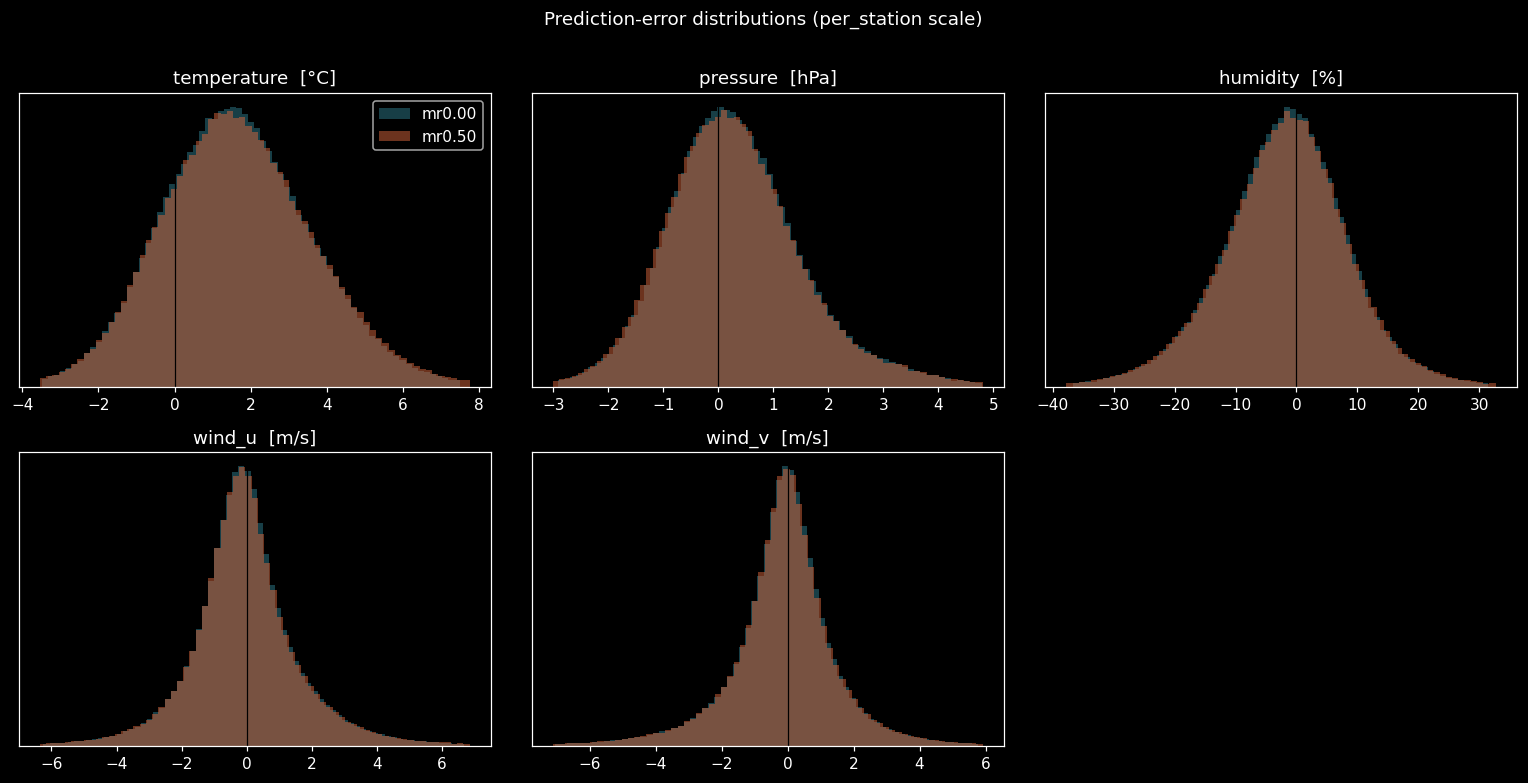

In [16]:
# ── Error distributions per variable (mr0.00 vs mr0.50) ──────────────────────
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, (vi, v) in zip(axes.ravel(), enumerate(VARS)):
    for mr, c in [("mr0.00","#2E7D8C"), ("mr0.50","#D9663D")]:
        err, mask = phys_errors(PRED[mr], scale=SCALE)
        e = err[..., vi][mask[..., vi]]
        lo, hi = np.percentile(e, [0.5, 99.5])
        ax.hist(e, bins=np.linspace(lo, hi, 70), density=True, alpha=0.5, color=c, label=mr)
    ax.axvline(0, color="k", lw=0.8)
    ax.set_title(f"{v}  [{UNITS[v]}]"); ax.set_yticks([])
axes.ravel()[0].legend()
axes.ravel()[-1].axis("off")
fig.suptitle(f"Prediction-error distributions ({SCALE} scale)", y=1.01)
plt.tight_layout(); plt.show()

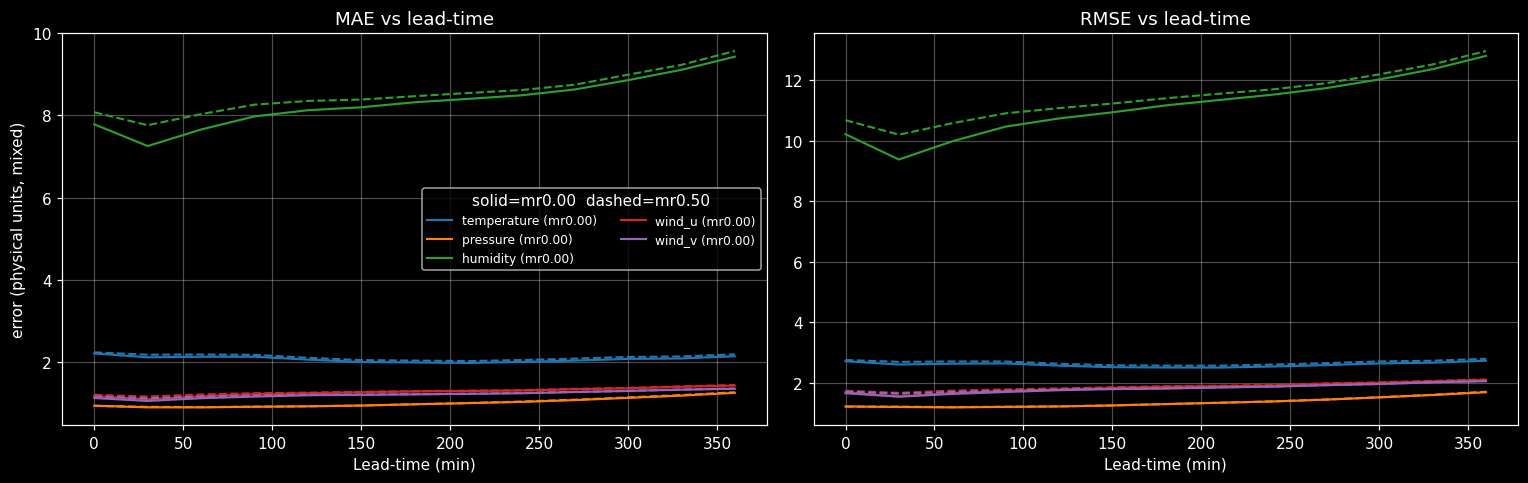

In [17]:
# ── MAE & RMSE vs lead-time, per variable ────────────────────────────────────
mins = (DELTA_GRID * 10)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
colors = plt.cm.tab10.colors
for mr, ls in [("mr0.00","-"), ("mr0.50","--")]:
    err, mask = phys_errors(PRED[mr], scale=SCALE)
    for vi, v in enumerate(VARS):
        mae_k, rmse_k = [], []
        for k in range(len(DELTA_GRID)):
            e = err[:, k, :, vi][mask[:, k, :, vi]]
            mae_k.append(np.mean(np.abs(e))); rmse_k.append(np.sqrt(np.mean(e**2)))
        axes[0].plot(mins, mae_k,  ls, color=colors[vi], lw=1.4,
                     label=f"{v} ({mr})" if mr=="mr0.00" else None)
        axes[1].plot(mins, rmse_k, ls, color=colors[vi], lw=1.4)
axes[0].set_title("MAE vs lead-time");  axes[1].set_title("RMSE vs lead-time")
for ax in axes:
    ax.set_xlabel("Lead-time (min)"); ax.grid(alpha=0.3)
axes[0].set_ylabel("error (physical units, mixed)")
axes[0].legend(fontsize=8, ncol=2, title="solid=mr0.00  dashed=mr0.50")
plt.tight_layout(); plt.show()

In [18]:
# ── |error| percentile + tail table (variability detail) ─────────────────────
def tail_table(mr):
    err, mask = phys_errors(PRED[mr], scale=SCALE)
    rows = {}
    for vi, v in enumerate(VARS):
        ae = np.abs(err[..., vi][mask[..., vi]])
        rows[v] = {"p50": np.percentile(ae,50), "p90": np.percentile(ae,90),
                   "p95": np.percentile(ae,95), "p99": np.percentile(ae,99),
                   "max": ae.max(), "RMSE/MAE": np.sqrt(np.mean(ae**2))/np.mean(ae)}
    return pd.DataFrame(rows).T

for mr in ["mr0.00","mr0.50"]:
    display(tail_table(mr).style.format("{:.3f}")
            .set_caption(f"{mr} — |error| percentiles & tail ratio ({SCALE} scale)"))

,p50,p90,p95,p99,max,RMSE/MAE
temperature,1.750,4.251,5.046,6.752,15.411,1.255
pressure,0.778,2.143,2.776,4.200,10.939,1.344
humidity,6.473,17.640,22.248,34.497,104.473,1.341
wind_u,0.866,2.861,3.837,6.457,20.139,1.455
wind_v,0.787,2.777,3.834,6.533,19.703,1.498


,p50,p90,p95,p99,max,RMSE/MAE
temperature,1.780,4.359,5.185,6.989,14.714,1.258
pressure,0.785,2.140,2.780,4.253,10.850,1.340
humidity,6.599,18.136,22.932,35.668,108.797,1.344
wind_u,0.875,2.903,3.909,6.615,19.802,1.459
wind_v,0.796,2.818,3.893,6.626,19.939,1.498


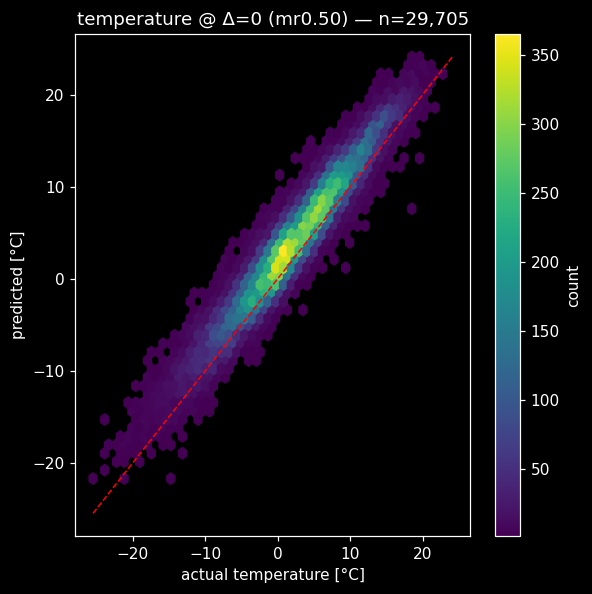

In [19]:
# ── (optional) predicted vs actual at Δ=0, one variable (physical) ───────────
VAR = "temperature"; vi = VARS.index(VAR); mr = "mr0.50"
d = PRED[mr]
if std_ps is not None:
    p = d["preds"][:,0,:,vi]    * std_ps[:,vi] + mean_ps[:,vi]
    t = d["targets"][:,0,:,vi]  * std_ps[:,vi] + mean_ps[:,vi]
    m = d["masks"][:,0,:,vi] > 0.5
    p, t = p[m], t[m]
    fig, ax = plt.subplots(figsize=(5.5,5.5))
    hb = ax.hexbin(t, p, gridsize=45, mincnt=1, cmap="viridis")
    lim = [min(t.min(),p.min()), max(t.max(),p.max())]
    ax.plot(lim, lim, "r--", lw=1)
    ax.set_xlabel(f"actual {VAR} [{UNITS[VAR]}]"); ax.set_ylabel(f"predicted [{UNITS[VAR]}]")
    ax.set_title(f"{VAR} @ Δ=0 ({mr}) — n={m.sum():,}")
    plt.colorbar(hb, ax=ax, label="count"); plt.tight_layout(); plt.show()
else:
    print("Per-station stats needed for physical scatter — skipped.")

## Version comparison — v9 vs v11 (mr0.50)

Two windows comparing the two training runs on the masked (gap-fill + forecast) setting.
Errors are on the **global physical reference scale** (`err_norm × global_std[v]`, derived
from v11's `test_metrics.csv`); the scale is identical for both runs, so the comparison is
fair. *(No v10 in the folder — using v9 and v11.)*

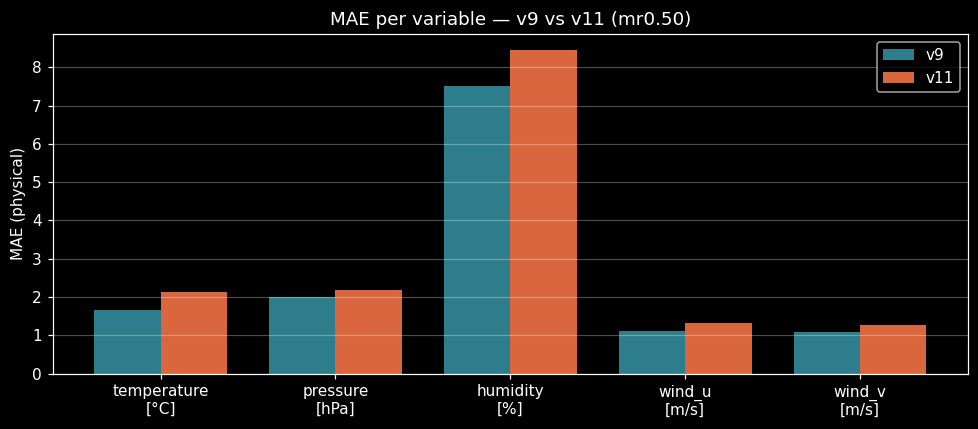

In [21]:
# ── Window 1: general results per variable (v9 vs v11, mr0.50) ────────────────
import csv as _csv
CMP_VERSIONS = ["v9", "v11"]
RESULTS_DIR = "test_results"

# Common global physical scale (same for both runs) from v11's metrics
_r = list(_csv.DictReader(open(os.path.join(RESULTS_DIR, "v11", "test_metrics.csv"))))[0]
g_std_cmp = np.array([float(_r[f"{v}_rmse"]) / float(_r[f"{v}_norm_rmse"]) for v in VARS])

CMP = {ver: load_pred(os.path.join(RESULTS_DIR, ver, "best_mr0.50", "predictions.pt"))
       for ver in CMP_VERSIONS}

def cmp_metrics(d):
    rows = {}
    for vi, v in enumerate(VARS):
        err  = (d["preds"][..., vi] - d["targets"][..., vi]) * g_std_cmp[vi]
        e    = err[d["masks"][..., vi] > 0.5]
        rows[v] = {"MAE": float(np.mean(np.abs(e))),
                   "RMSE": float(np.sqrt(np.mean(e**2))),
                   "bias": float(np.mean(e))}
    return pd.DataFrame(rows).T

tabs = {ver: cmp_metrics(CMP[ver]) for ver in CMP_VERSIONS}
comp = pd.concat({ver: tabs[ver] for ver in CMP_VERSIONS}, axis=1)
comp[("Δ", "MAE v11−v9")] = tabs["v11"]["MAE"] - tabs["v9"]["MAE"]
display(comp.style.format("{:+.3f}")
        .set_caption("v9 vs v11 — mr0.50, physical units ("
                     + ", ".join(f"{v} [{UNITS[v]}]" for v in VARS) + ")"))

# grouped bar chart of MAE per variable
x = np.arange(len(VARS)); w = 0.38
fig, ax = plt.subplots(figsize=(9, 4))
for i, (ver, c) in enumerate(zip(CMP_VERSIONS, ["#2E7D8C", "#D9663D"])):
    ax.bar(x + (i-0.5)*w, tabs[ver]["MAE"].values, w, label=ver, color=c)
ax.set_xticks(x); ax.set_xticklabels([f"{v}\n[{UNITS[v]}]" for v in VARS])
ax.set_ylabel("MAE (physical)"); ax.set_title("MAE per variable — v9 vs v11 (mr0.50)")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

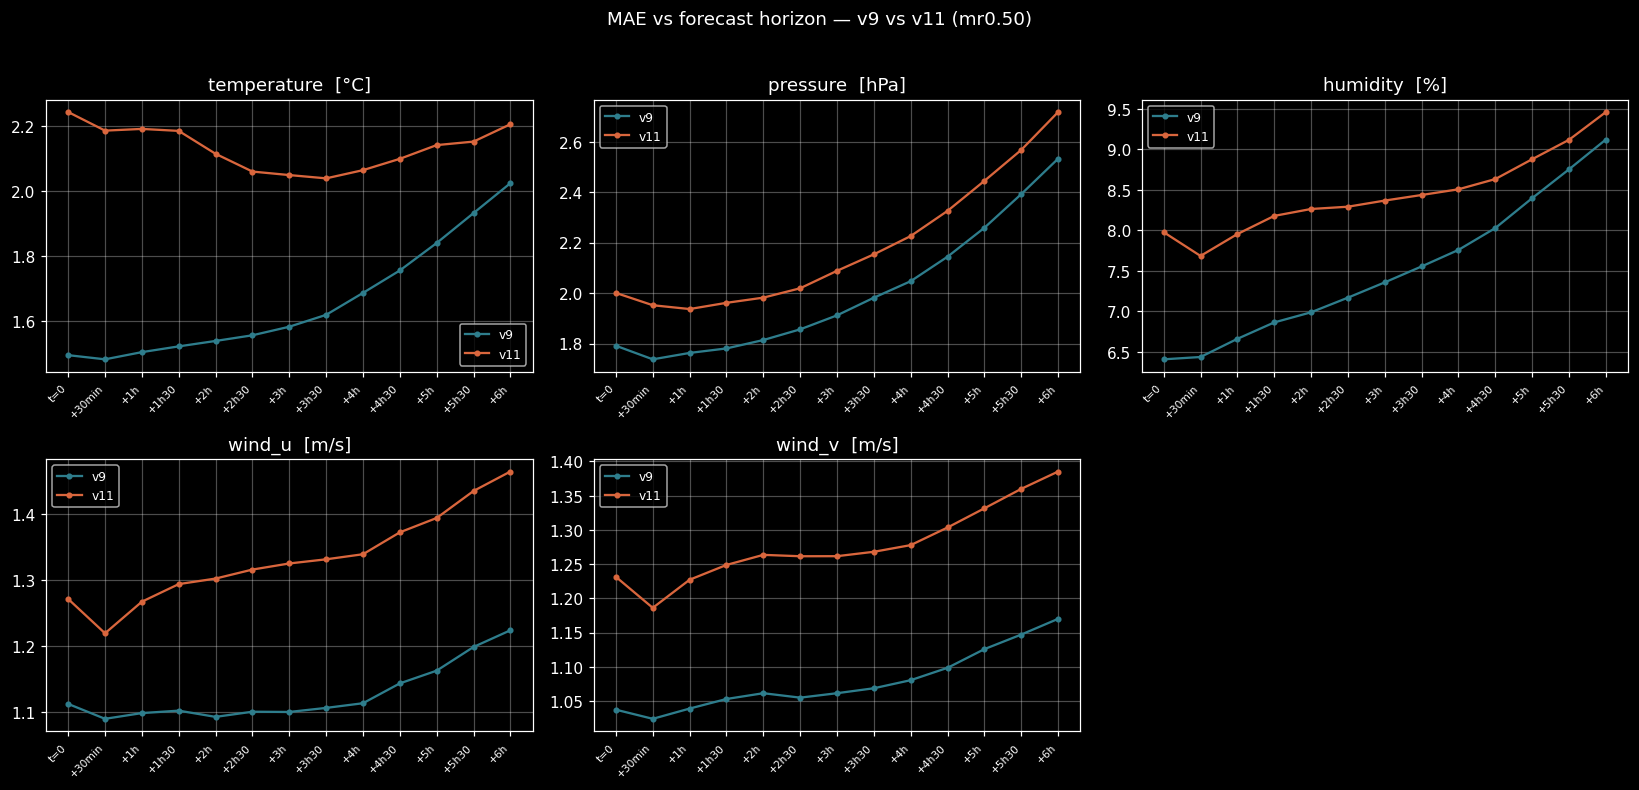

In [22]:
# ── Window 2: temporal — MAE vs forecast horizon (v9 vs v11, mr0.50) ──────────
def fmt_lead(steps):
    m = int(steps) * 10
    if m == 0:      return "t=0"
    if m < 60:      return f"+{m}min"
    if m % 60 == 0: return f"+{m//60}h"
    return f"+{m//60}h{m%60:02d}"

grid   = CMP["v9"]["delta_steps"][0].astype(int)
labels = [fmt_lead(s) for s in grid]
K      = len(grid)

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, (vi, v) in zip(axes.ravel(), enumerate(VARS)):
    for ver, c in zip(CMP_VERSIONS, ["#2E7D8C", "#D9663D"]):
        d = CMP[ver]
        mae = []
        for k in range(K):
            e = (d["preds"][:, k, :, vi] - d["targets"][:, k, :, vi]) * g_std_cmp[vi]
            e = e[d["masks"][:, k, :, vi] > 0.5]
            mae.append(np.mean(np.abs(e)))
        ax.plot(range(K), mae, "o-", color=c, lw=1.5, ms=3, label=ver)
    ax.set_xticks(range(K)); ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=7)
    ax.set_title(f"{v}  [{UNITS[v]}]"); ax.grid(alpha=0.3); ax.legend(fontsize=8)
axes.ravel()[-1].axis("off")
fig.suptitle("MAE vs forecast horizon — v9 vs v11 (mr0.50)", y=1.02)
plt.tight_layout(); plt.show()